# Time-Delay Filters

In [1]:
import jax
import jax.numpy as jnp

import matplotlib.pylab as plt

import WDM
from WDM.code.discrete_wavelet_transform import WDM

In [2]:
dt = 1.0

Nt = 256
Nf = 16
N = Nt*Nf

wdm = WDM.WDM_transform(dt=dt, Nf=Nf, N=N, q=8, calc_m0=True)

tables = wdm.build_time_delay_filter_interpolants(25, 10)

print(wdm)

WDM_transform(Nf=16, N=4096, q=8, d=4, A_frac=0.25, calc_m0=True)
self.Nt = 256 time cells
self.Nf = 16 frequency cells
self.dT = 16.0 time resolution
self.dF = 0.03125 frequency resolution
self.dt = 1.0 time series cadence
self.df = 0.000244140625 time series fft frequency resolution
self.K = 256 window length


In [3]:
import time

l = jnp.array([-2,-1,0,1,2])
delta = jnp.linspace(-105*wdm.dT, 15*wdm.dT, 1000)

t0 = time.time()
T = wdm.time_delay_filter_Tl(tables, l, delta)
print(T[0,0])
t1 = time.time()
print(t1-t0)

t0 = time.time()
T = wdm.time_delay_filter_Tl(tables, l, delta)
print(T[0,0])
t1 = time.time()
print(t1-t0)

0.0
4.18160605430603
0.0
0.0035550594329833984


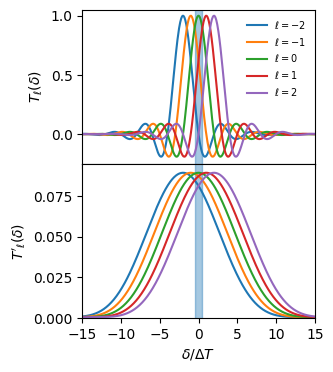

In [4]:
fig, axes = plt.subplots(nrows=2, figsize=(3, 4), sharex=True)

for l in [-2,-1,0,1,2]:
    l = jnp.array([l])
    delta  = jnp.linspace(-15*wdm.dT, 15*wdm.dT, 1000)

    Tl = wdm.time_delay_filter_Tl(tables, l, delta)[0]
    Tprimel = wdm.time_delay_filter_Tprimel(tables, l, delta)[0]
    
    axes[0].plot(delta/wdm.dT, Tl, label=r'$\ell='+str(l[0])+'$')
    axes[1].plot(delta/wdm.dT, Tprimel)

axes[0].fill_between([-0.5, 0.5], [2., 2.], [-2., -2.], color='C0', alpha=0.4)
axes[0].set_xlim(-15, 15)
axes[0].set_ylim(-0.25, 1.05)
axes[0].set_ylabel(r"$T_\ell(\delta)$")
axes[0].legend(loc='upper right', fontsize=7, frameon=False)

axes[1].fill_between([-0.5, 0.5], [2., 2.], [-2., -2.], color='C0', alpha=0.4)
axes[1].set_xlim(-15, 15)
axes[1].set_ylim(0.0, 0.095)
axes[1].set_xticks([-15, -10, -5, 0, 5, 10, 15])
axes[1].set_yticks([0, 0.025, 0.05, 0.075])
axes[1].set_ylabel(r"$T'_\ell(\delta)$")
axes[1].set_xlabel(r"$\delta/\Delta T$")

plt.subplots_adjust(hspace=0)
plt.show()

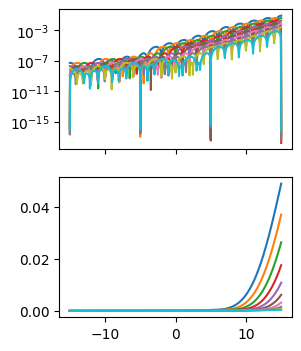

In [5]:
from WDM.code.time_delay_filters.filters import time_delay_filter_Tl_reference, time_delay_filter_Tprimel_reference

fig, axes = plt.subplots(nrows=2, figsize=(3, 4), sharex=True)
for l in range(20, 30):
    l = jnp.array([l])
    delta  = jnp.linspace(-15*wdm.dT, 15*wdm.dT, 1000)

    Tl = jnp.array([time_delay_filter_Tl_reference(l, d, wdm.freqs, wdm.window_FD, wdm.dT, wdm.df) for d in delta])
    Tprimel = jnp.array([time_delay_filter_Tprimel_reference(l, d, wdm.freqs, wdm.window_FD, wdm.dT, wdm.dF, wdm.N, wdm.df) for d in delta])

    axes[0].plot(delta/wdm.dT, jnp.abs(Tl))
    axes[1].plot(delta/wdm.dT, jnp.abs(Tprimel))

axes[0].set_yscale('log')

plt.show()

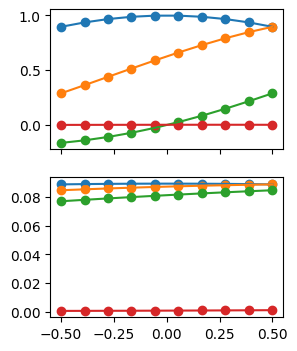

In [6]:
fig, axes = plt.subplots(nrows=2, figsize=(3, 4), sharex=True)

for l in [0,1,2,13]:
    axes[0].scatter(wdm.delta_interp_grid/wdm.dT, wdm.list_of_Tl_functions[l+wdm.max_lag_L].values)
    axes[0].plot(wdm.delta_interp_grid/wdm.dT, wdm.list_of_Tl_functions[l+wdm.max_lag_L].values)

    axes[1].scatter(wdm.delta_interp_grid/wdm.dT, wdm.list_of_Tprimel_functions[l+wdm.max_lag_L].values)
    axes[1].plot(wdm.delta_interp_grid/wdm.dT, wdm.list_of_Tprimel_functions[l+wdm.max_lag_L].values)

plt.show()

In [7]:
wdm.Cnm

Array([[1.+0.j, 0.+1.j, 1.+0.j, ..., 0.+1.j, 1.+0.j, 0.+1.j],
       [0.+1.j, 1.+0.j, 0.+1.j, ..., 1.+0.j, 0.+1.j, 1.+0.j],
       [1.+0.j, 0.+1.j, 1.+0.j, ..., 0.+1.j, 1.+0.j, 0.+1.j],
       ...,
       [0.+1.j, 1.+0.j, 0.+1.j, ..., 1.+0.j, 0.+1.j, 1.+0.j],
       [1.+0.j, 0.+1.j, 1.+0.j, ..., 0.+1.j, 1.+0.j, 0.+1.j],
       [0.+1.j, 1.+0.j, 0.+1.j, ..., 1.+0.j, 0.+1.j, 1.+0.j]],      dtype=complex128)

In [8]:
n = jnp.arange(10)

m = jnp.arange(20)

((-1)**(n[:,jnp.newaxis] * m[jnp.newaxis,:])).shape

(10, 20)

In [9]:
wdm.Nt, wdm.Nf

(256, 16)

In [10]:
n = jnp.arange(Nt)
m = jnp.arange(Nf)

(1j)**((n[:,jnp.newaxis] + m[jnp.newaxis,:])%2) - wdm.Cnm

Array([[0.000000e+00+0.j, 6.123234e-17+0.j, 0.000000e+00+0.j, ...,
        6.123234e-17+0.j, 0.000000e+00+0.j, 6.123234e-17+0.j],
       [6.123234e-17+0.j, 0.000000e+00+0.j, 6.123234e-17+0.j, ...,
        0.000000e+00+0.j, 6.123234e-17+0.j, 0.000000e+00+0.j],
       [0.000000e+00+0.j, 6.123234e-17+0.j, 0.000000e+00+0.j, ...,
        6.123234e-17+0.j, 0.000000e+00+0.j, 6.123234e-17+0.j],
       ...,
       [6.123234e-17+0.j, 0.000000e+00+0.j, 6.123234e-17+0.j, ...,
        0.000000e+00+0.j, 6.123234e-17+0.j, 0.000000e+00+0.j],
       [0.000000e+00+0.j, 6.123234e-17+0.j, 0.000000e+00+0.j, ...,
        6.123234e-17+0.j, 0.000000e+00+0.j, 6.123234e-17+0.j],
       [6.123234e-17+0.j, 0.000000e+00+0.j, 6.123234e-17+0.j, ...,
        0.000000e+00+0.j, 6.123234e-17+0.j, 0.000000e+00+0.j]],      dtype=complex128)

In [11]:
(1j)**jnp.array([0,1,2])

Array([ 1.000000e+00+0.0000000e+00j,  6.123234e-17+1.0000000e+00j,
       -1.000000e+00+1.2246468e-16j], dtype=complex128)

In [12]:
import time

def func(n):
    ans = 0
    for i in range(n):
        ans += i
    return ans

@jax.jit
def func_(n):
    def body_fun(i, ans):
        return ans + i

    return jax.lax.fori_loop(0, n, body_fun, 0)

t0 = time.time()
x = func(100_000_000)
t1 = time.time()
print(f"{x = } (time taken {t1-t0:.3f})")

t0 = time.time()
x = func_(100_000_000)
t1 = time.time()
print(f"{x = } (time taken {t1-t0:.3f})")

t0 = time.time()
x = func_(100_000_000)
t1 = time.time()
print(f"{x = } (time taken {t1-t0:.3f})")

x = 4999999950000000 (time taken 2.105)
x = Array(4999999950000000, dtype=int64, weak_type=True) (time taken 0.165)
x = Array(4999999950000000, dtype=int64, weak_type=True) (time taken 0.153)
